# Prueba práctica analista de datos - Pragma

## Parte 2

### 1. Definición del problema y contexto de negocio

Uno de nuestros clientes actuales se dedica a la importación y venta de mercancía a través de un portal de internet. Por lo que para este cliente la Tasa de Cambio Representativa del Mercado (TCRM) es de gran interés.

***a. Encuentre la TCRM para la fecha de la expedición de su propia cédula.***

**Valor TCRM para 2017-11-22:** $3001.07 COP.

***b. ¿Están completos los datos?,¿Cuántos días no se transaron?, cree una función para llenar los datos faltantes.***

* Los datos presentan días sin información de la TCRM. Según lo observado en la serie, no se transaron 3724 días.

* Para generar la función, se tiene en cuenta el comportamiento del mercado, en el que se repite el valor del último día hábil, durante los días en que este permanece cerrado. Se utiliza la fecha mínima y fecha máxima observada en la serie, se generan todas las fechas dentro de este rango y posteriormente se utiliza la función [`ffill()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ffill.html) para realizar un proceso de forward fill, en donde se toma el último valor disponible de la serie para rellenar los valores faltantes de las fechas posteriores. Con este proceso, la serie con los datos completos tiene 10912 observaciones, correspondiente a la cantidad fe chas esperada a partir de la fecha mínima (1991-12-02) y máxima (2021-10-16).

***c. Grafique la TCMR contra el tiempo y haga un análisis de la curva observada.***

La serie correponde a la Tasa de Cambio Representativa del Mercado (TCRM) y cuenta con observaciones diarias, desde el 2 de diciembre de 1991 hasta el 16 de octubre de 2021. Del análisis de la gráfica se identifica:

* Se presenta una tendencia creciente a largo plazo, con una subida fuerte en el período de 1991 a 2003, una caída durante 2003 a 2014 y un incremento con punto máximo en el año 2020.

* No se observa un componente estacional; los picos y caídas observados pueden estar ligados a distintos factores económicos sin un comportamiento que se reputa regularmente en determinados puntos.

* La variabilidad de la serie aumenta a medida que aumenta su nivel. En losprimeros años la serie flutua mucho menos que durante los últimos años observados, dond elos cambios día a día son más nototios.

* Los valores de la serie persisten, siendo notorio que al haber picos o caídas, la serie tiende a mantenerse en estos niveles en lugar de regresar a su comportamiento previo.

Los cambios de nivel y tendencia de la serie, junto con el cambio en la variabilidad sugieren que la serie no es estacionaria, lo cual indica que la media y la varianza cambian a lo largo del tiempo. Con esto presente, el análisis posterior implica considerar el logaritmo del TCRM para estrabilizal la varianza, y posiblemente aplicar diferencia para corregir estacionaridad (comprobación posterior).

***d. De acuerdo al histórico cuál sería la TCRM para el primero de enero de 2023. Cree un modelo de forecast para determinarlo. ¿Cuál es la desviación estándar estimada?***

El proceso  de modelación tuvo en cuenta lo siguiente: 

**1. Preparación de los datos:** El archivo original tiene 7188 observaciones que representan la TCRM en un rango de vigencia determinado (Entre 1 y 6 días). Al ser una serie que no está regularmente espaciada, no se puede utilizar para un forecast directamente. Los datos con información imputada para los días que no se transaron contienen información repetida para esos días, por lo que subestiman la variabilidad real de la serie. Con esto presente, se usaron los datos imputados filtrando solo durante los días hábiles de la serie, que contienen información real del TCRM. Con esto, se tiene que N = 7795, teniendo un registro por día hábil y sin información artifical d elos días que no se transaron.

**2. Análisis de la serie y elección del modelo:** Utilizando el logaritmo de la serie, se dividió la serie en conjunto de datos de entrenamiento (`train_df <= 2020-08-02`) y conjunto de datos de prueba (`test_df > 2020-08-02`); se comprobó gráficamente y a través de la prueba ADF, que la serie no es estacionaria (p-value > 0.05, no hay evidencia suficiente para rechazar $H_O$: No estacionaridad). Para corregir esto, se aplicó la primera diferencia y se observó que la serie pasó a ser estacionaria ya que los valores se estabilizan alrededor del cero. Con esto, se concluyó que el orden $d = 1$. Luego se observaron las gráficas de ACF y PACF, en donde se determinó $q = 1$ y $p = 1$. Para complementar el análisis, se realizó un ajuste auto_arima que permitiera identificar y comparar el modelo obtenido y seleccionar el mejor para el pronósticO, de donde se observó que la función auto_arima identificó como mejor modelo un ARIMA(0,1,1).Con estos dos modelos y utilizando MAPE, AIC y BIC, se observaron comportamientos similares respecto al MAPE, mientras que en AIC y BIC el modelo identificado con la función auto_arima, ARIMA(0,1,1) obtuvo mejores resultados.

**3. Ajuste del modelo y pronóstico:** Considerando el modelo ARIMA(0,1,1) seleccionado a partir de los criterios de información AIC y BIC, se realizo un reajuste considerando la serie completa, con datos desde 1991-12-02 hasta 2021-10-16, aprovechando toda la información disponible. Se calculó el horizonte de días hábiles posteriores hasta la fecha objetivo 2023-01-01, y se obtuvo el pronóstico, primero en escala logarítmica dado la transofrmación aplciada a la serie, y luego en su escala original (COP). Se obtuvo lo siguiente:

**Pronóstico para 2023-01-01:** $ 4031.94 COP

**Intervalo de confianza (95%):** [$ 3161.40 COP, $ 5142.19 COP]

**Desviación estándar estimada:** $ 500.35 COP

La desviación estándar estimadade $500.35 COP muestra qla variación estimada del TCRM para el período de pronóstico, según el modelo.

**4. Pronóstico vs valor real:** El valor real para el TCRM en el período 2023-01-01 fue de $ 4810.20 COP. Contrastando esto con los resultados del modelo, se observa que el valor se encuentra dentro del IC al 95% estimado por el modelo, lo cual muestra que el modelo es confiable, aún con la alta volatilidad del período a pronosticar derivada de factores macroeconómicos posteriores a la pandemia.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
data_tcrm = pd.read_excel('../data/raw/Tasa_de_Cambio_Representativa_del__Mercado_Historico.xlsx')

In [3]:
data_tcrm.shape
data_tcrm.info()
data_tcrm['VALOR'] = data_tcrm['VALOR'].str.replace(',', '').astype(float)
data_tcrm.info()

<class 'pandas.DataFrame'>
RangeIndex: 7188 entries, 0 to 7187
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   VALOR          7188 non-null   str           
 1   UNIDAD         7188 non-null   str           
 2   VIGENCIADESDE  7188 non-null   datetime64[us]
 3   VIGENCIAHASTA  7188 non-null   datetime64[us]
dtypes: datetime64[us](2), str(2)
memory usage: 224.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 7188 entries, 0 to 7187
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   VALOR          7188 non-null   float64       
 1   UNIDAD         7188 non-null   str           
 2   VIGENCIADESDE  7188 non-null   datetime64[us]
 3   VIGENCIAHASTA  7188 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(1), str(1)
memory usage: 224.8 KB


In [4]:
data_tcrm.head()

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
0,2850.98,COP,2002-10-09,2002-10-09
1,2854.04,COP,2002-10-10,2002-10-10
2,2870.63,COP,2002-10-11,2002-10-11
3,2861.16,COP,2002-10-12,2002-10-15
4,2852.99,COP,2002-10-16,2002-10-16


In [5]:
# a. Encuentre la TCRM para la fecha de la expedición de su propia cédula.
fecha_cedula = '2017-11-22'
data_tcrm[(data_tcrm['VIGENCIADESDE'] <= fecha_cedula) & (data_tcrm['VIGENCIAHASTA'] >= fecha_cedula)]

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
1823,3001.07,COP,2017-11-22,2017-11-22


In [7]:
# b. ¿Están completos los datos?,¿Cuántos días no se transaron?, cree una función para llenar los datos faltantes

data_tcrm = data_tcrm.sort_values('VIGENCIADESDE').reset_index(drop=True)

f_min = data_tcrm['VIGENCIADESDE'].min()
f_max = data_tcrm['VIGENCIADESDE'].max()

rango = pd.DataFrame({'fecha': pd.date_range(f_min, f_max, freq='D')})

dias_faltantes = rango[~rango['fecha'].isin(data_tcrm['VIGENCIADESDE'])]

cant_dias_esperados = len(rango)
cant_dias_faltantes = len(dias_faltantes)
cant_dias_tcrm = len(data_tcrm)

print(f'Dias esperados: {cant_dias_esperados}')
print(f'Dias transados según los datos: {cant_dias_tcrm}')
print(f'Dias faltantes: {cant_dias_faltantes}')

Dias esperados: 10912
Dias transados según los datos: 7188
Dias faltantes: 3724


In [8]:
def llenar_datos_faltantes(data_frame, fecha):
    data_frame = data_frame.sort_values(fecha).reset_index(drop=True)
    f_min = data_frame[fecha].min()
    f_max = data_frame[fecha].max()
    rango = pd.date_range(f_min, f_max, freq='D')

    data_frame = data_frame.set_index(fecha)
    data_frame = data_frame.reindex(rango)

    data_frame = data_frame.ffill()

    data_frame = data_frame.reset_index()
    data_frame = data_frame.rename(columns = {'index': fecha})

    return data_frame

In [9]:
data_tcrm_completo = llenar_datos_faltantes(data_tcrm, 'VIGENCIADESDE')

In [10]:
data_tcrm_completo.shape

(10912, 4)

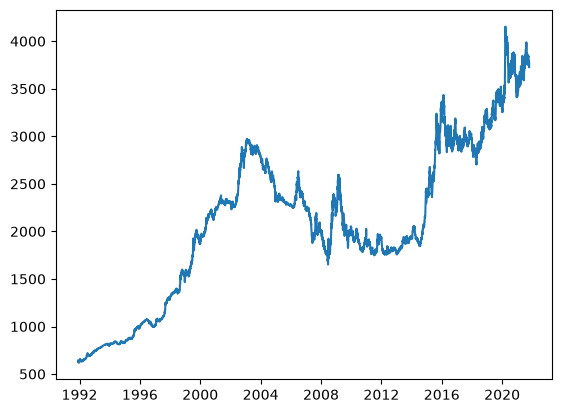

In [11]:
# c. Grafique la TCMR contra el tiempo y haga un análisis de la curva observada

plt.plot(data_tcrm['VIGENCIADESDE'], data_tcrm['VALOR'])

In [12]:
data_tcrm['dias_vigencia'] = (data_tcrm['VIGENCIAHASTA'] - data_tcrm['VIGENCIADESDE']).dt.days + 1

data_tcrm['dias_vigencia'].value_counts()

dias_vigencia
1    5529
3    1117
4     403
2      91
5      47
6       1
Name: count, dtype: int64

In [13]:
data_tcrm_completo['dia_habil'] = data_tcrm_completo['VIGENCIADESDE'].dt.dayofweek

data_tcrm_completo = data_tcrm_completo[data_tcrm_completo['dia_habil'] < 5]

data_tcrm_completo.shape

(7795, 5)

In [14]:
# se copian los datos y se asignan fecha como indice
df = data_tcrm_completo.copy()

df = df.sort_values('VIGENCIADESDE').reset_index(drop=True)
df = df.set_index('VIGENCIADESDE')

In [15]:
fecha_corte = '2020-08-02'
train_df = df.loc[:fecha_corte].copy()
test_df = df.loc[fecha_corte:].iloc[1:].copy()

print(len(train_df))
print(len(test_df))

7480
314


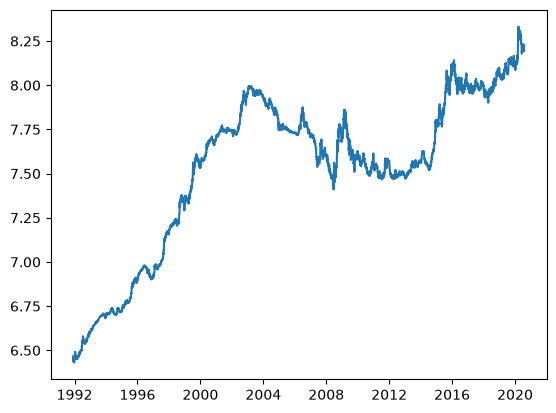

In [16]:
train_df['log_VALOR'] = np.log(train_df['VALOR'])
plt.plot(train_df.index, train_df['log_VALOR'])

In [17]:
adf = adfuller(train_df['log_VALOR'])

print('ADF:', adf[0])
print('p-value:', adf[1])
# p-value > 0.05, por lo que la serie no es estacionaria y hay que diferenciarla

train_df['diff_log_VALOR'] = train_df['log_VALOR'].diff()

adf_d = adfuller(train_df['diff_log_VALOR'].dropna())

print('ADF:', adf_d[0])
print('p-value:', adf_d[1])
# luego de la primera diferencia hay un cambio abrupto pero en el gráfico se observa los valores estables así que d=1

ADF: -1.8819714675053385
p-value: 0.3405892473675104
ADF: -15.415691375639408
p-value: 3.0815591795951685e-28


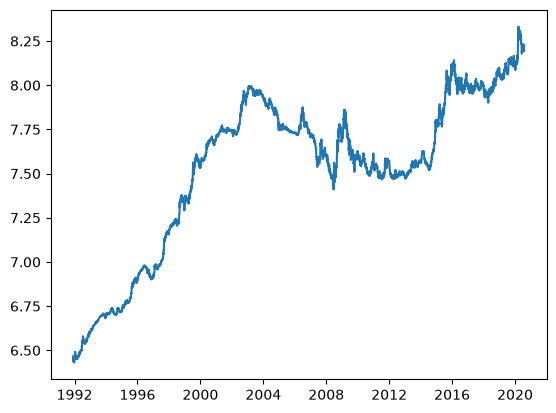

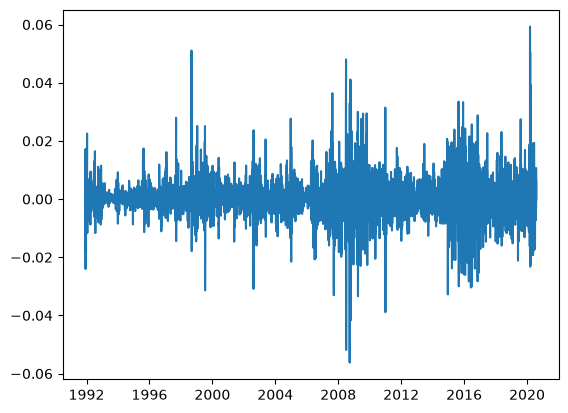

In [18]:
plt.plot(train_df['log_VALOR'])
plt.show()

plt.plot(train_df['log_VALOR'].diff())
plt.show()

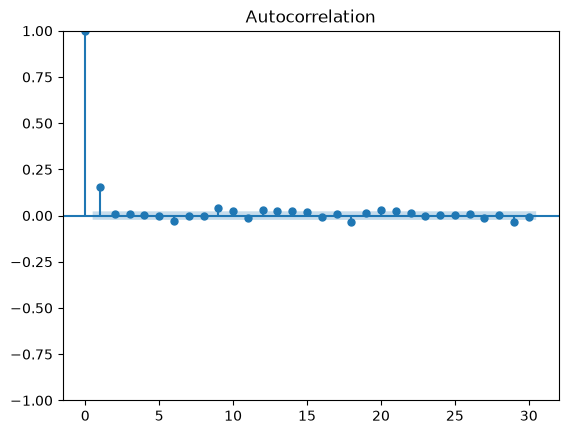

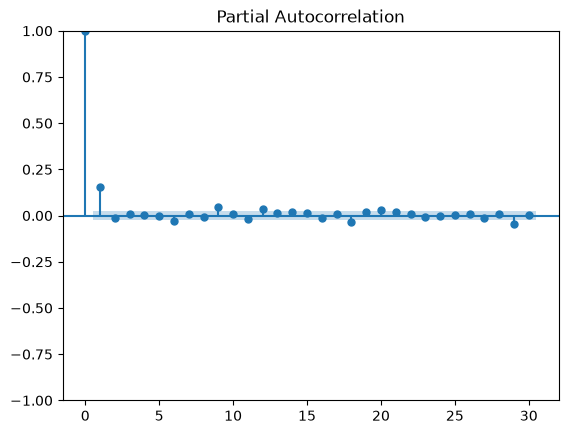

In [19]:
diff_log = train_df['diff_log_VALOR'].dropna()

plot_acf(diff_log, lags=30)
plt.show() 
# q = 1, desde donde cae

plot_pacf(diff_log, lags=30, method='ywm')
plt.show()
# p = 1, desde donde cae

In [20]:
modelo_1 = pm.ARIMA(order=(1, 1, 1))
modelo_1.fit(train_df['log_VALOR'])

c:\Users\Stephany.Lobo\OneDrive - insidemedia.net\Escritorio\Prueba\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Stephany.Lobo\OneDrive - insidemedia.net\Escritorio\Prueba\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


,order,"(1, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


In [22]:
modelo_2 = pm.auto_arima(train_df['log_VALOR'], seasonal=False, stepwise=True, trace=True, error_action='ignore', suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-55252.721, Time=2.02 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-55076.746, Time=0.52 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-55256.781, Time=0.53 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-55257.639, Time=3.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-55067.584, Time=1.93 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-55256.262, Time=1.47 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-55256.175, Time=1.22 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-55254.560, Time=0.69 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-55251.093, Time=0.45 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 12.108 seconds


In [23]:
forecast_1_log, conf_int_1 = modelo_1.predict(n_periods=len(test_df), return_conf_int=True)
forecast_1_val = np.exp(forecast_1_log)
mape_1 = mean_absolute_percentage_error(test_df['VALOR'], forecast_1_val)

forecast_2_log, conf_int_2 = modelo_2.predict(n_periods=len(test_df), return_conf_int=True)
forecast_2_val = np.exp(forecast_2_log)

mape_2 = mean_absolute_percentage_error(test_df['VALOR'], forecast_2_val)

resultados = pd.DataFrame({'Modelo': ['ARIMA(1,1,1)', 'AutoARIMA (0,1,1)'],
                           'MAPE': [mape_1, mape_2],
                           'AIC': [modelo_1.aic(), modelo_2.aic()],
                           'BIC': [modelo_1.bic(), modelo_2.bic()]})

resultados['MAPE %'] = resultados['MAPE'] * 100

resultados.sort_values('MAPE')
# son muy parecidos en MAPE, aic y bic es mejor auto arima, y es un modelo más sencillo (parsimonioso)

,Modelo,MAPE,AIC,BIC,MAPE %
0,"ARIMA(1,1,1)",0.053647,-55256.262489,-55228.583072,5.364700
1,"AutoARIMA (0,1,1)",0.053768,-55257.639436,-55236.879873,5.376806


In [24]:
# reajuste con todos los datos del mejor modelo
serie_completa = pd.concat([train_df['log_VALOR'], 
                                 np.log(test_df['VALOR'])])
serie_completa = serie_completa.sort_index()

print("Total observaciones:", len(serie_completa)) 

Total observaciones: 7794


In [25]:
modelo_final = pm.ARIMA(order=(0,1,1))
modelo_final.fit(serie_completa)

c:\Users\Stephany.Lobo\OneDrive - insidemedia.net\Escritorio\Prueba\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Stephany.Lobo\OneDrive - insidemedia.net\Escritorio\Prueba\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,order,"(0, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


In [26]:
ultima_fecha = serie_completa.index[-1]
fecha_objetivo = pd.Timestamp('2023-01-01')
h = len(pd.bdate_range(ultima_fecha, fecha_objetivo)) - 1

print(f"Ultima fecha: {ultima_fecha.date()}")
print(f"h = {h}") # periodo apronosticar

Ultima fecha: 2021-10-15
h = 315


In [27]:
forecast_log, conf_int_log = modelo_final.predict(n_periods=h, return_conf_int=True, alpha=0.05)

pronostico_log = forecast_log.iloc[-1]
ci_lower_log, ci_upper_log = conf_int_log[-1]

pronostico_cop = np.exp(pronostico_log)
ci_lower = np.exp(ci_lower_log)
ci_upper = np.exp(ci_upper_log)

se_log = (ci_upper_log - ci_lower_log) / (2 * 1.96)
sd_estim = pronostico_cop * se_log

print(f"Pronostico TCRM 2023-01-01: {pronostico_cop}")
print(f"IC 95%: [{ci_lower}, {ci_upper}]")
print(f"Desviacion estandar estimada: {sd_estim} COP")

Pronostico TCRM 2023-01-01: 4031.9403686694654
IC 95%: [3161.4046271350144, 5142.189961061316]
Desviacion estandar estimada: 500.3541519939826 COP


c:\Users\Stephany.Lobo\OneDrive - insidemedia.net\Escritorio\Prueba\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Stephany.Lobo\OneDrive - insidemedia.net\Escritorio\Prueba\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
